# Global plots

The goal of this script is to create figure that summarize the results of the different analysis and quantifications.

In [98]:
import tifffile
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas import DataFrame, Series  # for convenience
from pathlib import Path
import seaborn as sns
from matplotlib.legend_handler import HandlerTuple
from statannotations.Annotator import Annotator
from matplotlib.patches import Patch
import warnings
import sys

my_path = Path.cwd().parent.parent / "src"
sys.path.append(str(my_path))

from visualization import visualization, plots
from utils import utils

%matplotlib inline

In [99]:
ROOT = Path(r"K:\users\voland\data\current\General_stats")

# 4 hours post fertilisation
PATH_4HPF = ROOT/"4hpf"
CT_4HPF_PATH = PATH_4HPF/"ct.csv"
CS_4HPF_PATH =  PATH_4HPF/"cs.csv"

# 1 day post fertilisation
PATH_1DPF = ROOT/"1dpf"
CT_1DPF_PATH = PATH_1DPF/"ct.csv"
CS_1DPF_PATH =  PATH_1DPF/"cs.csv"
H2B_1DPF_PATH = PATH_1DPF/"h2b.csv"
OTHER_1DPF_PATH = PATH_1DPF/"other.csv"

# 2 day post fertilisation
PATH_2DPF = ROOT/"2dpf"
CT_2DPF_PATH = PATH_2DPF/"ct.csv"
CS_2DPF_PATH =  PATH_2DPF/"cs.csv"
H2B_2DPF_PATH = PATH_2DPF/"h2b.csv"
OTHER_2DPF_PATH = PATH_2DPF/"other.csv"

# 3 day post fertilisation
PATH_3DPF = ROOT/"3dpf"
CT_3DPF_PATH = PATH_3DPF/"ct.csv"
CS_3DPF_PATH =  PATH_3DPF/"cs.csv"
H2B_3DPF_PATH = PATH_3DPF/"h2b.csv"
OTHER_3DPF_PATH = PATH_3DPF/"other.csv"

In [100]:
CT_CS_PALETTE = {"Cetn2Eos": "darkseagreen", "CenSpark": "mediumpurple"}

In [101]:
ct_4hpf = pd.read_csv(CT_4HPF_PATH,)
cs_4hpf = pd.read_csv(CS_4HPF_PATH)

ct_1dpf = pd.read_csv(CT_1DPF_PATH)
cs_1dpf = pd.read_csv(CS_1DPF_PATH)
h2b_1dpf = pd.read_csv(H2B_1DPF_PATH)
other_1dpf = pd.read_csv(OTHER_1DPF_PATH)

ct_2dpf = pd.read_csv(CT_2DPF_PATH)
cs_2dpf = pd.read_csv(CS_2DPF_PATH)
h2b_2dpf = pd.read_csv(H2B_2DPF_PATH)
other_2dpf = pd.read_csv(OTHER_2DPF_PATH)

ct_3dpf = pd.read_csv(CT_3DPF_PATH)
cs_3dpf = pd.read_csv(CS_3DPF_PATH)
h2b_3dpf = pd.read_csv(H2B_3DPF_PATH)
other_3dpf = pd.read_csv(OTHER_3DPF_PATH)

In [102]:
ct_4hpf["marker"],ct_1dpf["marker"],ct_2dpf["marker"],ct_3dpf["marker"] ="Cetn2Eos","Cetn2Eos","Cetn2Eos","Cetn2Eos"
cs_4hpf["marker"],cs_1dpf["marker"],cs_2dpf["marker"],cs_3dpf["marker"] ="CenSpark","CenSpark","CenSpark","CenSpark"

ct_4hpf["day"],ct_1dpf["day"],ct_2dpf["day"],ct_3dpf["day"] =0,1,2,3
cs_4hpf["day"],cs_1dpf["day"],cs_2dpf["day"],cs_3dpf["day"] =0,1,2,3

h2b_1dpf["day"],h2b_2dpf["day"],h2b_3dpf["day"] = 1,2,3
other_1dpf["day"],other_2dpf["day"],other_3dpf["day"] = 1,2,3

In [103]:
def create_estimation_col(foci_df):
    if "nb" in foci_df.columns:
        foci_df["est_nb"] = np.where(foci_df["nb"].notna(),foci_df["nb"],foci_df["auto_nb"] * foci_df["nb_factor"])
    if "auto_coloc" in foci_df.columns:
        foci_df["est_coloc"] = np.where(foci_df["coloc"].notna(),foci_df["coloc"],foci_df["auto_coloc"] * foci_df["coloc_factor"])
        foci_df["epr"] = np.where(foci_df["pr"].notna(),foci_df["pr"],foci_df["apr"] * 0.95)
        foci_df["eupr"] = np.where(foci_df["upr"].notna(),foci_df["upr"],foci_df["aupr"] * 0.95)
        foci_df["epi"] = np.where(foci_df["pi"].notna(),foci_df["pi"],foci_df["api"] * 0.95)
        foci_df["eupi"] = np.where(foci_df["upi"].notna(),foci_df["upi"],foci_df["aupi"] * 0.95)
    elif "coloc" in foci_df.columns:
        foci_df["est_coloc"] = foci_df["coloc"]
        foci_df["epr"] = foci_df["pr"]
        foci_df["eupr"] = foci_df["upr"]
        foci_df["epi"] = foci_df["pi"]
        foci_df["eupi"] = foci_df["upi"]

    return foci_df

In [104]:
ct_4hpf = create_estimation_col(ct_4hpf)
ct_1dpf = create_estimation_col(ct_1dpf)
ct_2dpf = create_estimation_col(ct_2dpf)
ct_3dpf = create_estimation_col(ct_3dpf)

cs_4hpf = create_estimation_col(cs_4hpf)
cs_1dpf = create_estimation_col(cs_1dpf)
cs_2dpf = create_estimation_col(cs_2dpf)
cs_3dpf = create_estimation_col(cs_3dpf)

In [105]:
h2b_1dpf = create_estimation_col(h2b_1dpf)
h2b_2dpf = create_estimation_col(h2b_2dpf)
h2b_3dpf = create_estimation_col(h2b_3dpf)

In [106]:
other_1dpf["est_dist"] = np.where(other_1dpf["dist"].notna(),other_1dpf["dist"],other_1dpf["auto_dist"] * other_1dpf["dist_factor"])
other_2dpf["est_dist"] = np.where(other_2dpf["dist"].notna(),other_2dpf["dist"],other_2dpf["auto_dist"] * other_2dpf["dist_factor"])
other_3dpf["est_dist"] = np.where(other_3dpf["dist"].notna(),other_3dpf["dist"],other_3dpf["auto_dist"] * other_3dpf["dist_factor"])

In [107]:
def create_foci_df(ct_df,cs_df,day):
    foci_df = ct_df.loc[:,["exp_idx","label"]]

    ct_percentage = ct_df["nb"]/(ct_df["nb"] + cs_df["nb"]) * 100
    foci_df["ct_percentage"] = ct_percentage 
    foci_df["cs_percentage"] = 100 - ct_percentage 
    foci_df["double_pos"] = ct_df["nb"]*ct_df["coloc"]/100

    auto_ct_percentage = ct_df["auto_nb"]/(ct_df["auto_nb"] + cs_df["auto_nb"]) * 100
    foci_df["auto_ct_percentage"] = auto_ct_percentage 
    foci_df["auto_cs_percentage"] = 100 - auto_ct_percentage 
    foci_df["auto_double_pos"] = ct_df["auto_nb"]*ct_df["auto_coloc"]/100

    est_ct_percentage = ct_df["est_nb"]/(ct_df["est_nb"] + cs_df["est_nb"]) * 100
    foci_df["est_ct_percentage"] = est_ct_percentage 
    foci_df["est_cs_percentage"] = 100 - est_ct_percentage 
    foci_df["est_double_pos"] = ct_df["est_nb"]*ct_df["est_coloc"]/100

    
    foci_df["day"] = day
    return foci_df

In [108]:
foci_4hpf = pd.concat([ct_4hpf,cs_4hpf])
foci_1dpf = create_foci_df(ct_1dpf,cs_1dpf,1)
foci_2dpf = create_foci_df(ct_2dpf,cs_2dpf,2)
foci_3dpf = create_foci_df(ct_3dpf,cs_3dpf,3)

In [109]:
foci_1dpf

,exp_idx,label,ct_percentage,cs_percentage,double_pos,auto_ct_percentage,auto_cs_percentage,auto_double_pos,est_ct_percentage,est_cs_percentage,est_double_pos,day
0,1,"""3e1""",NaN,NaN,197.910,NaN,NaN,158.097,NaN,NaN,197.910000,1
1,1,"""3e3""",64.586847,35.413153,269.632,71.664168,28.335832,271.982,64.586847,35.413153,269.632000,1
2,1,"""3e4""",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,1,"""3e5""",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,2,"""1e1""",NaN,NaN,NaN,54.119548,45.880452,242.875,52.103439,47.896561,241.903500,1
5,2,"""1e3""",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
6,2,"""1e7""",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
7,2,"""2e1""",NaN,NaN,NaN,50.956938,49.043062,171.039,48.932990,51.067010,170.354844,1
8,2,"""2e7""",NaN,NaN,NaN,51.361868,48.638132,191.928,49.338017,50.661983,191.160288,1
9,2,"""3e4""",NaN,NaN,NaN,60.353535,39.646465,248.082,58.400801,41.599199,247.089672,1


## Time point analysis

### Proportion visulaisation

In [110]:
# Reshape the dataframe to plot the data more easily
auto_percentage_df = pd.melt(
    foci_1dpf,
    value_vars=["auto_ct_percentage", "auto_cs_percentage"],
    var_name="marker",
    value_name="percentage"
)

# Rename for clean x labels
auto_percentage_df["marker"] = auto_percentage_df["marker"].map({
    "auto_ct_percentage": "Cetn2Eos",
    "auto_cs_percentage": "CenSpark"
})

Text(0.5, 1.0, 'Proportion of auto-detected foci marker among total detection')

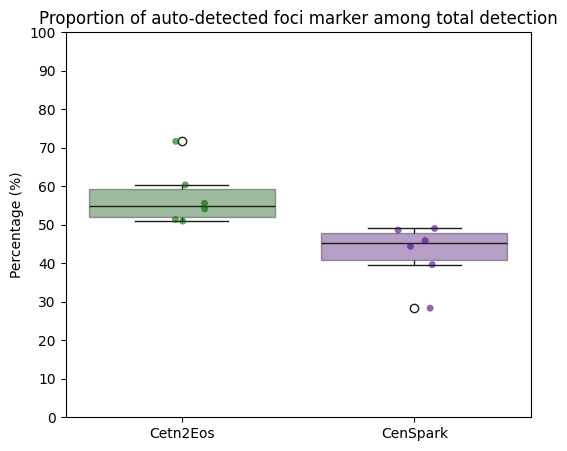

In [111]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(
    data = auto_percentage_df,
    x = "marker",
    hue = "marker",
    y = "percentage",
    palette = {"Cetn2Eos": "darkgreen", "CenSpark": "indigo"},
    order = ["Cetn2Eos", "CenSpark"],
    boxprops={'alpha': 0.4},
    ax = ax,
)
sns.stripplot(data=auto_percentage_df, x="marker",hue = "marker", y="percentage", palette = {"Cetn2Eos": "darkgreen", "CenSpark": "indigo"},alpha=0.6,
    order = ["Cetn2Eos", "CenSpark"], ax=ax)
ax.set_xlabel("")
ax.set_ylim([0,100])
ax.set_yticks(np.arange(0,110,10))
ax.set_ylabel("Percentage (%)")
ax.set_title("Proportion of auto-detected foci marker among total detection")

Text(0.5, 1.0, 'Proportion of auto-detected foci marker among total detection')

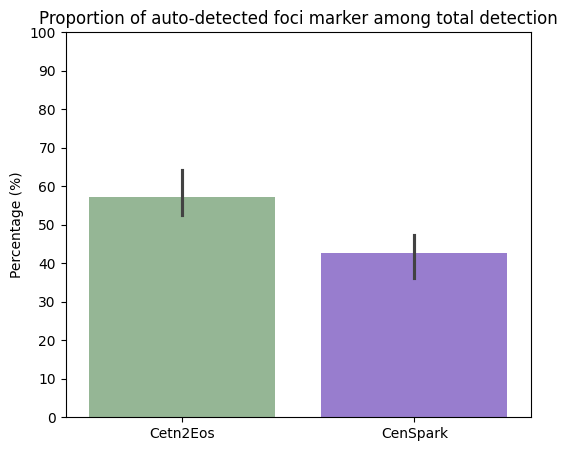

In [112]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(
    data = auto_percentage_df,
    x = "marker",
    hue = "marker",
    y = "percentage",
    palette = {"Cetn2Eos": "darkseagreen", "CenSpark": "mediumpurple"},
    order = ["Cetn2Eos", "CenSpark"],
    #boxprops={'alpha': 0.4},
    ax = ax,
)
ax.set_xlabel("")
ax.set_ylim([0,100])
ax.set_yticks(np.arange(0,110,10))
ax.set_ylabel("Percentage (%)")
ax.set_title("Proportion of auto-detected foci marker among total detection")

C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\3303890338.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([""])


Text(0.5, 1.0, 'Proportion of auto-detected foci marker among total detection at 1dpf')

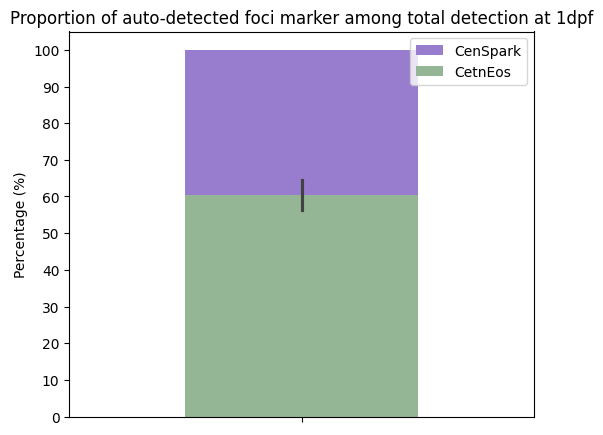

In [113]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(
    x = 1,
    y = [100],  
    color = "mediumpurple",
    label="CenSpark",
    width = 0.5,
    ax = ax
)
sns.barplot(
    data = foci_1dpf,
    x = 1,
    y = "ct_percentage",
    color = "darkseagreen",
    label="CetnEos",
    width = 0.5,
    ax = ax,
)

ax.set_xlabel("")
ax.set_ylim([0,105])
ax.set_yticks(np.arange(0,110,10))
ax.set_ylabel("Percentage (%)")
ax.set_xticklabels([""])
ax.set_title("Proportion of auto-detected foci marker among total detection at 1dpf")

Text(0.5, 1.0, 'Mean foci distribution')

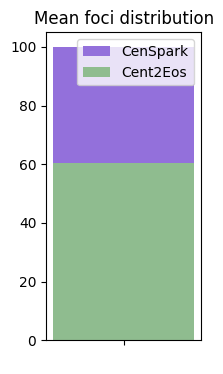

In [114]:
plt.figure(figsize=(2,4))
plt.bar(x =" ", height=100,color = "mediumpurple",width=0.3)
plt.bar(x =" ", height=foci_1dpf["ct_percentage"].mean(),color = "darkseagreen",width=0.3)
plt.legend(["CenSpark","Cent2Eos"])
plt.title("Mean foci distribution")


Text(0.5, 1.0, 'Number of auto-detected double positive foci per half a somite')

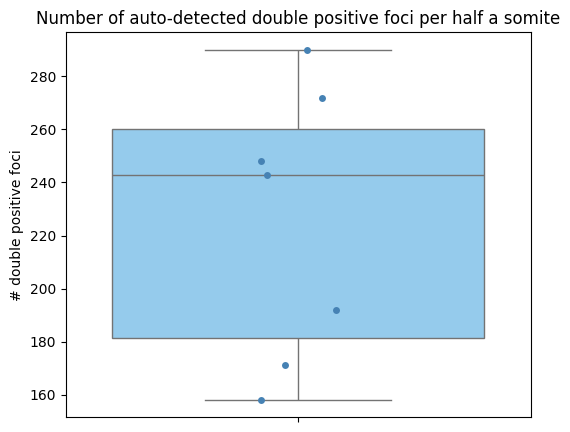

In [115]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(
    data = foci_1dpf,
    y = "auto_double_pos",
    color ="lightskyblue",
    ax = ax,
)
sns.stripplot(data = foci_1dpf,
    y = "auto_double_pos",
    color ="steelblue",
      ax=ax)
ax.set_ylabel("# double positive foci")
ax.set_title("Number of auto-detected double positive foci per half a somite")

C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\3148994282.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([""])


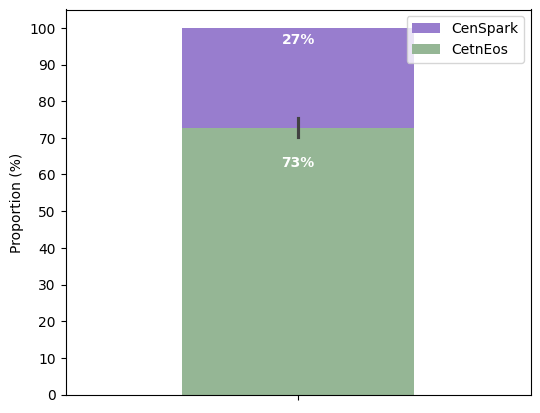

In [116]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(
    x = 1,
    y = [100],  
    color = "mediumpurple",
    label="CenSpark",
    width = 0.5,
    ax = ax
)
sns.barplot(
    data = ct_4hpf,
    x = 1,
    y = "prop",
    color = "darkseagreen",
    label="CetnEos",
    width = 0.5,
    ax = ax,
)

ax.set_xlabel("")
ax.set_ylim([0,105])
ax.set_yticks(np.arange(0,110,10))
ax.set_ylabel("Proportion (%)")
ax.set_xticklabels([""])

rects = ax.patches
labels = [str(100-73)]
for rect, label in zip(rects[0:1], labels):
    height = rect.get_height()
    ax.text(
        rect.get_x() + rect.get_width() / 2, height -5, label + "%", ha="center", va="bottom", color = "white", fontweight = "bold"
    )


for i in range(1,2):
    ax.bar_label(ax.containers[i],label_type="edge",padding=-30,fmt='%.0f%%', color = "white",fontweight="bold") 

#ax.set_title("Proportion of auto-detected foci marker among total detection at 1dpf")

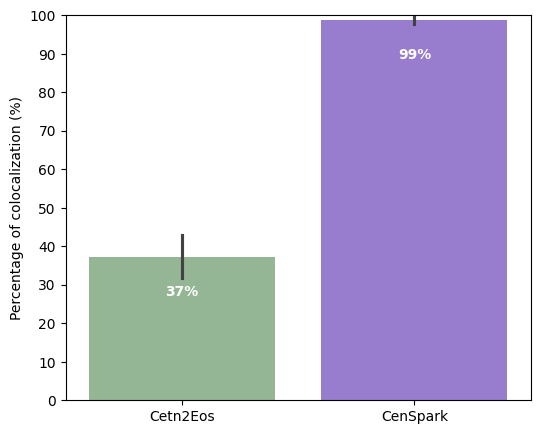

In [117]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(
    data = foci_4hpf,
    x = "marker",
    hue = "marker",
    y = "coloc",
    palette = {"Cetn2Eos": "darkseagreen", "CenSpark": "mediumpurple"},
    order = ["Cetn2Eos", "CenSpark"],
    ax = ax,
)
ax.set_xlabel("")
ax.set_ylim([0,100])
ax.set_yticks(np.arange(0,110,10))
ax.set_ylabel("Percentage of colocalization (%)")

for i in range(0,2):
    ax.bar_label(ax.containers[i],label_type="edge",padding=-30,fmt='%.0f%%', color = "white",fontweight="bold") 

#ax.set_title("Proportion of colocalisation for each marker at 4hpf")

### Featrures 

#### Zdiff

(0.0, 1.0)

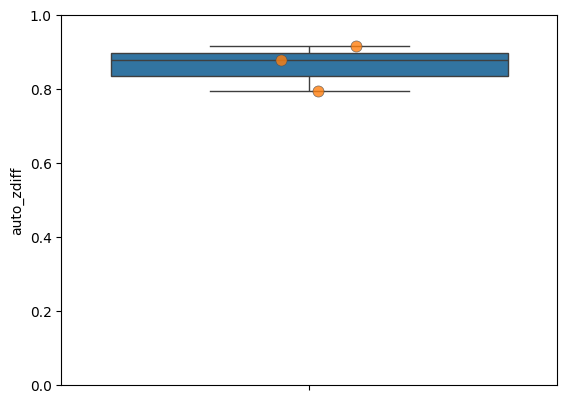

In [118]:
other_1dpf
ax = sns.boxplot(
    data = other_1dpf,
    y = "auto_zdiff"
)
sns.stripplot(data = other_1dpf,
    y = "auto_zdiff",
    alpha=0.8,
    linewidth=0.5,  
    size=8,
    legend=False,
    ax=ax
)
ax.set_ylim([0,1])

#### Radius

In [119]:
auto_radius_ct_1dpf = pd.melt(
    ct_1dpf,
    value_vars=["apr", "aupr"],
    var_name="paired",
    value_name="radius"
)


auto_radius_cs_1dpf = pd.melt(
    cs_1dpf,
    value_vars=["apr", "aupr"],
    var_name="paired",
    value_name="radius"
)

auto_radius_ct_1dpf["paired"] = auto_radius_ct_1dpf["paired"].map({
    "apr": "Paired",
    "aupr": "Unpaired"
})

auto_radius_cs_1dpf["paired"] = auto_radius_cs_1dpf["paired"].map({
    "apr": "Paired",
    "aupr": "Unpaired"
})

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Paired vs. Unpaired: Mann-Whitney-Wilcoxon test two-sided, P_val:4.206e-01 U_stat=1.700e+01
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Paired vs. Unpaired: Mann-Whitney-Wilcoxon test two-sided, P_val:6.905e-01 U_stat=1.500e+01


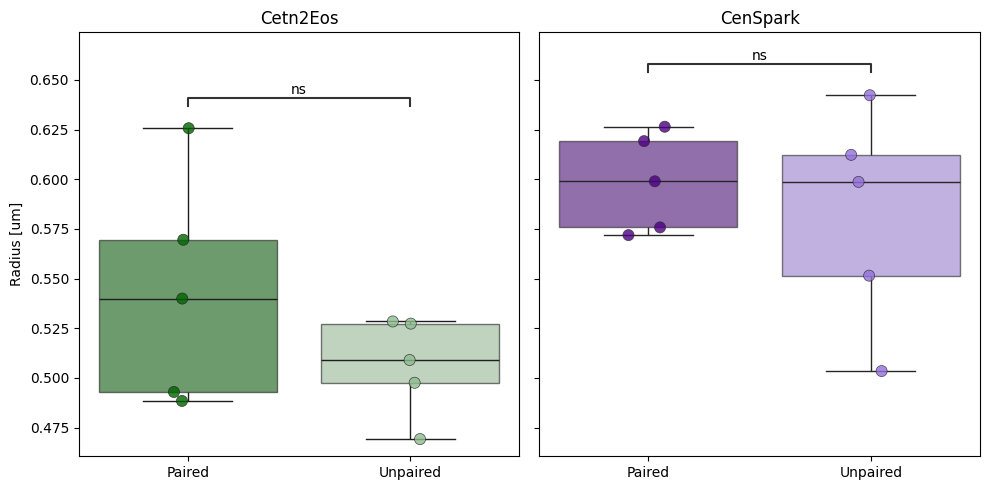

In [120]:
plots.plot_sns_comparison_box_plot(
    auto_radius_ct_1dpf,
    auto_radius_cs_1dpf,
    "paired",
    y="radius",
    hue="paired",
    title="Radius of paired vs unpaired auto-detected foci",
    units="Radius [um]",
    pairs = [("Paired", "Unpaired")]
)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Paired vs. Unpaired: t-test independent samples, P_val:2.196e-01 t=1.332e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Paired vs. Unpaired: t-test independent samples, P_val:5.477e-01 t=6.277e-01


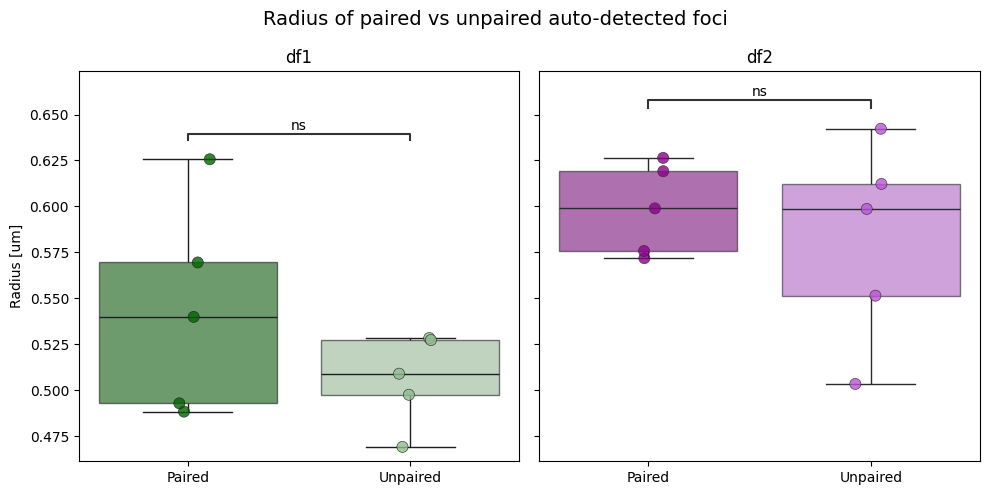

In [121]:
df1 = auto_radius_ct_1dpf
df2 = auto_radius_cs_1dpf
x = "paired"
y = "radius"
title = "Radius of paired vs unpaired auto-detected foci"
units = "Radius [um]"
pairs = [("Paired", "Unpaired")]

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

for ax, (name, df) in zip(axes, [("df1", df1), ("df2", df2)]):
    clean_df = df.dropna(subset=[x, y])

    palette = ["darkgreen", "darkseagreen"] if name == "df1" else ["darkmagenta", "mediumorchid"]

    sns.boxplot(
        data=clean_df,
        x=x,
        y=y,
        hue=x,
        palette=palette,
        boxprops={"alpha": 0.6},
        legend=False,
        ax=ax,
    )
    sns.stripplot(
        data=clean_df,
        x=x,
        y=y,
        hue=x,
        palette=palette,
        alpha=0.8,
        linewidth=0.5,
        size=8,
        legend=False,
        ax=ax,
    )

    annotator = Annotator(
        ax,
        pairs=pairs,
        data=clean_df,
        x=x,
        y=y,
    )
    annotator.configure(test="t-test_ind", text_format="star", loc="inside")
    annotator.apply_and_annotate()

    ax.set_title(name)
    ax.set_xlabel(None)
    ax.set_ylabel(units if ax is axes[0] else "")

fig.suptitle(title, fontsize=14)
plt.tight_layout()
plt.show()

In [122]:
radius_ct_1dpf = pd.melt(
    ct_1dpf,
    value_vars=["pr", "upr"],
    var_name="paired",
    value_name="radius"
)


radius_cs_1dpf = pd.melt(
    cs_1dpf,
    value_vars=["pr", "upr"],
    var_name="paired",
    value_name="radius"
)

radius_ct_1dpf["paired"] = radius_ct_1dpf["paired"].map({
    "pr": "Paired",
    "upr": "Unpaired"
})

radius_cs_1dpf["paired"] = radius_cs_1dpf["paired"].map({
    "pr": "Paired",
    "upr": "Unpaired"
})

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Paired vs. Unpaired: Mann-Whitney-Wilcoxon test two-sided, P_val:3.333e-01 U_stat=4.000e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Paired vs. Unpaired: Mann-Whitney-Wilcoxon test two-sided, P_val:3.333e-01 U_stat=0.000e+00


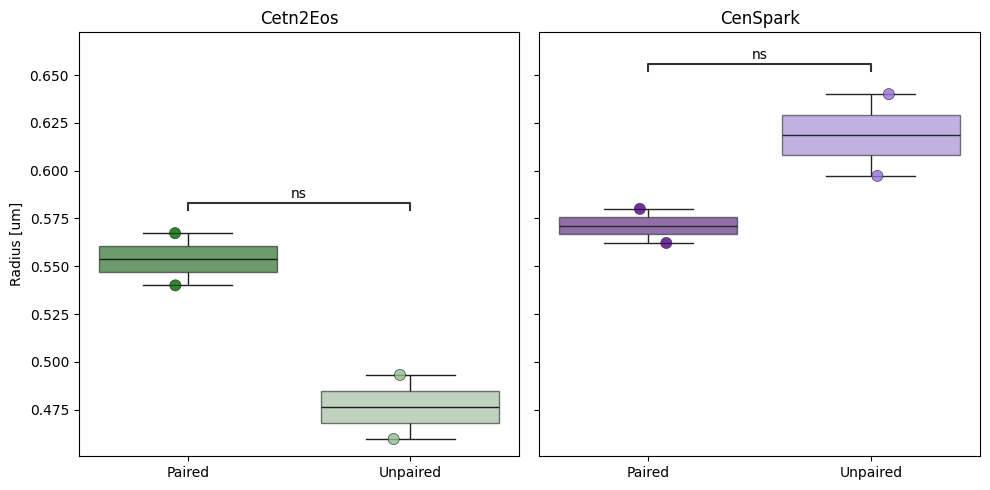

In [123]:
plots.plot_sns_comparison_box_plot(
    radius_ct_1dpf,
    radius_cs_1dpf,
    "paired",
    y="radius",
    hue="paired",
    title="Radius of paired vs unpaired foci",
    units="Radius [um]",
    pairs = [("Paired", "Unpaired")]
)

### Intensity

In [124]:
auto_intensity_ct_1dpf = pd.melt(
    ct_1dpf,
    value_vars=["api", "aupi"],
    var_name="paired",
    value_name="intensity"
)


auto_intensity_cs_1dpf = pd.melt(
    cs_1dpf,
    value_vars=["api", "aupi"],
    var_name="paired",
    value_name="intensity"
)

auto_intensity_ct_1dpf["paired"] = auto_intensity_ct_1dpf["paired"].map({
    "api": "Paired",
    "aupi": "Unpaired"
})

auto_intensity_cs_1dpf["paired"] = auto_intensity_cs_1dpf["paired"].map({
    "api": "Paired",
    "aupi": "Unpaired"
})

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Paired vs. Unpaired: Mann-Whitney-Wilcoxon test two-sided, P_val:4.206e-01 U_stat=1.700e+01
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Paired vs. Unpaired: Mann-Whitney-Wilcoxon test two-sided, P_val:3.175e-02 U_stat=2.300e+01


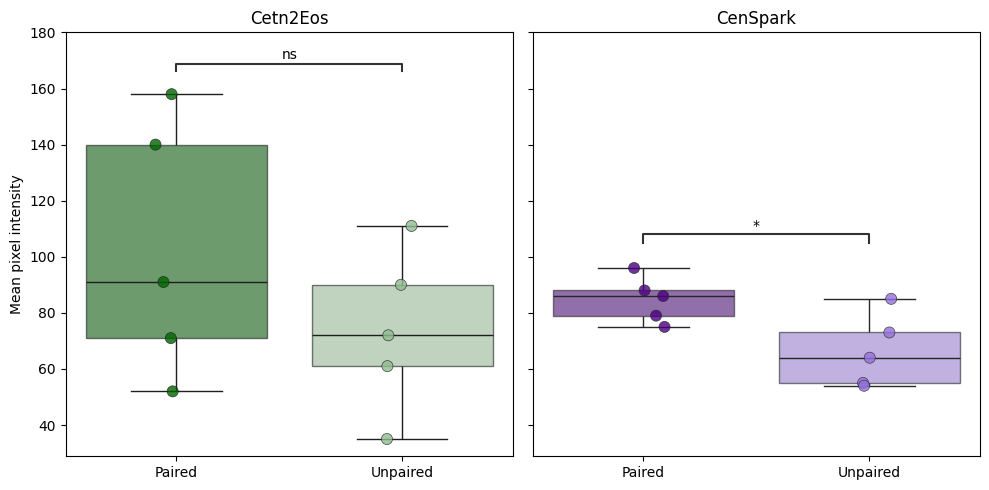

In [125]:
plots.plot_sns_comparison_box_plot(
    auto_intensity_ct_1dpf,
    auto_intensity_cs_1dpf,
    "paired",
    y="intensity",
    hue="paired",
    title="Mean intensity of paired vs unpaired auto-detected foci",
    units="Mean pixel intensity",
    pairs = [("Paired", "Unpaired")]
)

In [126]:
intensity_ct_1dpf = pd.melt(
    ct_1dpf,
    value_vars=["pi", "upi"],
    var_name="Colocalizing",
    value_name="intensity"
)


intensity_cs_1dpf = pd.melt(
    cs_1dpf,
    value_vars=["pi", "upi"],
    var_name="Colocalizing",
    value_name="intensity"
)

intensity_ct_1dpf["Colocalizing"] = intensity_ct_1dpf["Colocalizing"].map({
    "pi": "Yes",
    "upi": "No"
})

intensity_cs_1dpf["Colocalizing"] = intensity_cs_1dpf["Colocalizing"].map({
    "pi": "Yes",
    "upi": "No"
})

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Yes vs. No: Mann-Whitney-Wilcoxon test two-sided, P_val:6.667e-01 U_stat=3.000e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Yes vs. No: Mann-Whitney-Wilcoxon test two-sided, P_val:3.333e-01 U_stat=4.000e+00


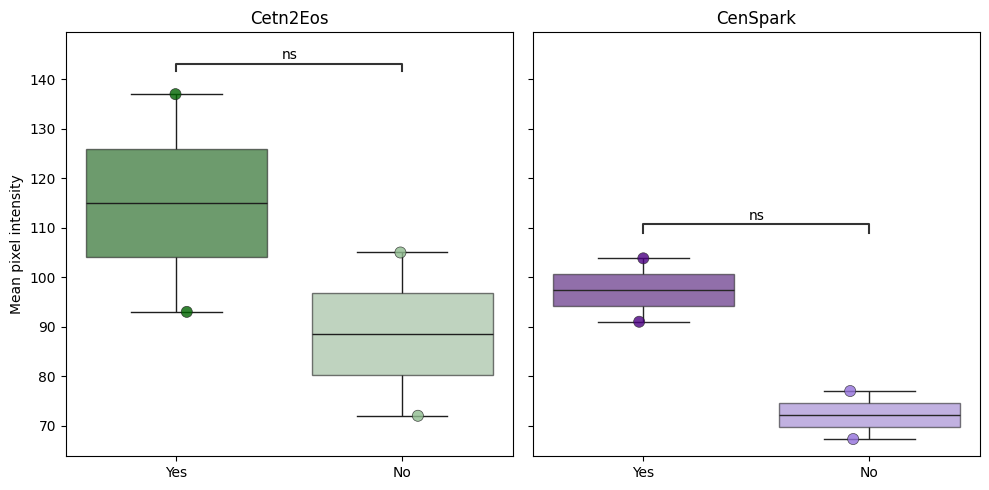

In [127]:
plots.plot_sns_comparison_box_plot(
    intensity_ct_1dpf,
    intensity_cs_1dpf,
    "Colocalizing",
    y="intensity",
    hue="Colocalizing",
    title="Mean intensity of paired vs unpaired auto-detected foci",
    units="Mean pixel intensity",
    pairs = [("Yes", "No")],
)

In [128]:
foci_1dpf["auto_ct_diff_int"] = ct_1dpf["api"] - ct_1dpf["aupi"]
foci_1dpf["auto_cs_diff_int"] = cs_1dpf["api"] - cs_1dpf["aupi"]

# Reshape the dataframe to plot the data more easily
auto_intensity_diff_df = pd.melt(
    foci_1dpf,
    value_vars=["auto_ct_diff_int", "auto_cs_diff_int"],
    var_name="marker",
    value_name="intensity"
)

# Rename for clean x labels
auto_intensity_diff_df["marker"] = auto_intensity_diff_df["marker"].map({
    "auto_ct_diff_int": "Cetn2Eos",
    "auto_cs_diff_int": "CenSpark"
})

C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\3569824116.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\3569824116.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data = auto_intensity_diff_df,


Text(0.5, 1.0, 'Mean intensity diff of paired vs unpaired auto detected foci')

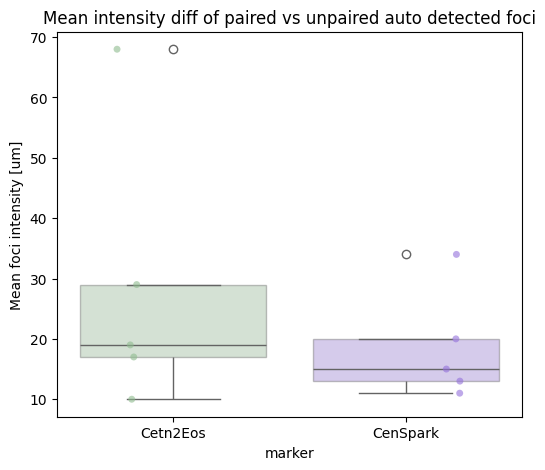

In [129]:

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(
    data = auto_intensity_diff_df,
    x = "marker",
    y = "intensity",
    #hue_order = ["paired","unpaired"],
    palette = CT_CS_PALETTE,
    boxprops={'alpha': 0.4},
    ax = ax,
)
sns.stripplot(data = auto_intensity_diff_df,
    x = "marker",
    y = "intensity",
    #hue_order = ["paired","unpaired"],
    palette = CT_CS_PALETTE,
    dodge=True,
    alpha=0.6,
    legend=False,
    ax=ax)
ax.set_ylabel("Mean foci intensity [um]")
ax.set_title("Mean intensity diff of paired vs unpaired auto detected foci")

## Temporal analysis

In [130]:
temporal_foci_df = pd.concat([foci_1dpf,foci_2dpf,foci_3dpf])
temporal_foci_df.head()

,exp_idx,label,ct_percentage,cs_percentage,double_pos,auto_ct_percentage,auto_cs_percentage,auto_double_pos,est_ct_percentage,est_cs_percentage,est_double_pos,day,auto_ct_diff_int,auto_cs_diff_int
0,1,"""3e1""",NaN,NaN,197.910,NaN,NaN,158.097,NaN,NaN,197.9100,1,NaN,NaN
1,1,"""3e3""",64.586847,35.413153,269.632,71.664168,28.335832,271.982,64.586847,35.413153,269.6320,1,NaN,NaN
2,1,"""3e4""",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN
3,1,"""3e5""",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN
4,2,"""1e1""",NaN,NaN,NaN,54.119548,45.880452,242.875,52.103439,47.896561,241.9035,1,19.0,15.0


In [131]:
temporal_h2b_df = pd.concat([h2b_1dpf,h2b_2dpf,h2b_3dpf])
temporal_h2b_df.head()

,exp_idx,label,auto_nb,nb,nb_factor,day,est_nb
0,1,"""3e1""",160,NaN,0.97,1,155.20
1,1,"""3e3""",187,150.0,0.97,1,150.00
2,1,"""3e4""",183,187.0,0.97,1,187.00
3,1,"""3e5""",207,NaN,0.97,1,200.79
4,2,"""1e1""",134,100.0,0.77,1,100.00


In [132]:
temporal_other_df = pd.concat([other_1dpf,other_2dpf, other_3dpf])
temporal_other_df.head()

,exp_idx,label,auto_zdiff,z_diff,auto_dist,dist,dist_factor,day,est_dist,zdiff
0,1,"""3e1""",NaN,NaN,NaN,NaN,1.3,1,NaN,NaN
1,1,"""3e3""",NaN,0.82,NaN,NaN,1.3,1,NaN,NaN
2,1,"""3e4""",NaN,NaN,NaN,0.7,1.3,1,0.700,NaN
3,1,"""3e5""",NaN,NaN,NaN,NaN,1.3,1,NaN,NaN
4,2,"""1e1""",NaN,NaN,1.21,NaN,1.3,1,1.573,NaN


### Proportion over time

C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\1942846458.py:3: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.barplot(


Text(0, 0.5, 'Proportion (%)')

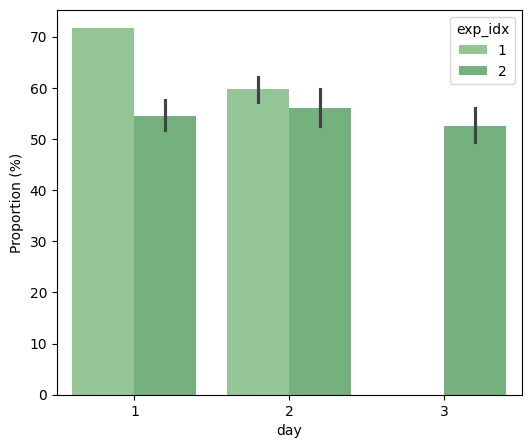

In [133]:
auto_proportion_df = temporal_foci_df[["day","exp_idx","auto_ct_percentage"]].dropna()
fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(
    data = auto_proportion_df,
    x = "day",
    hue="exp_idx",
    y = "auto_ct_percentage",
    hue_order = [1,2],
    palette=sns.color_palette(palette="Greens_d"),
    ax = ax,
)

ax.set_ylabel("Proportion (%)")
#ax.set_title("Proportion of Cetn2Eos foci over days")

C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\1026823739.py:3: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.barplot(


Text(0, 0.5, 'Proportion (%)')

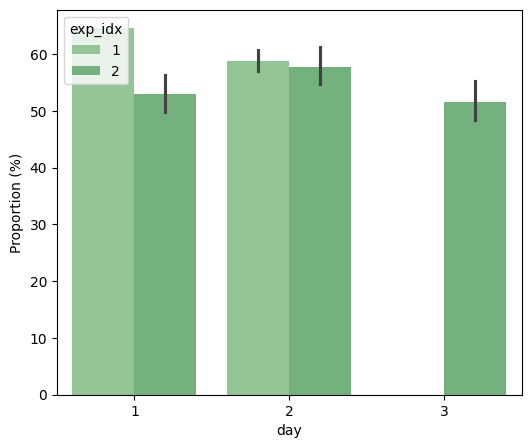

In [134]:
est_proportion_df = temporal_foci_df[["day","exp_idx","est_ct_percentage"]].dropna()
fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(
    data = est_proportion_df,
    x = "day",
    hue="exp_idx",
    y = "est_ct_percentage",
    hue_order = [1,2],
    palette=sns.color_palette(palette="Greens_d"),
    ax = ax,
)

ax.set_ylabel("Proportion (%)")
#ax.set_title("Proportion of Cetn2Eos foci over days")

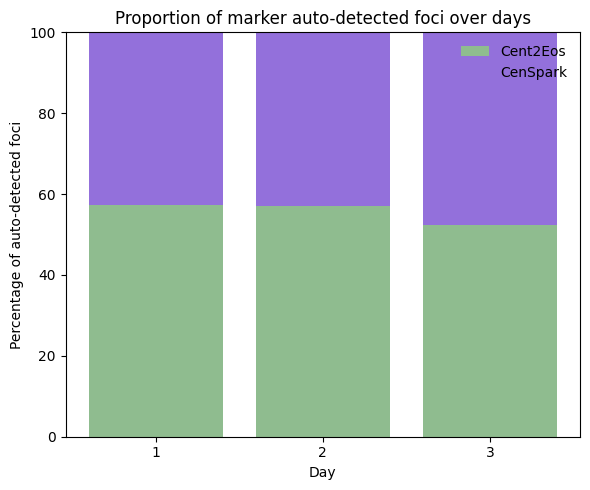

In [135]:
# Average percentage per day
plot_df = (
    temporal_foci_df
    .groupby("day")[["auto_ct_percentage", "auto_cs_percentage"]]
    .mean()
)

fig, ax = plt.subplots(figsize=(6, 5))

# Bottom bar (CT)
ax.bar(
    plot_df.index,
    plot_df["auto_ct_percentage"],
    color="darkseagreen",
    label="Cent2Eos",
)

# Top bar (CS)
ax.bar(
    plot_df.index,
    plot_df["auto_cs_percentage"],
    bottom=plot_df["auto_ct_percentage"],
    color="mediumpurple",
    label="CenSpark",
)

ax.set_ylim(0, 100)
ax.set_ylabel("Percentage of auto-detected foci")
ax.set_xlabel("Day")
ax.set_xticks([1,2,3])
ax.legend(frameon=False)

plt.title("Proportion of marker auto-detected foci over days")
plt.tight_layout()
plt.show()

As the correction factor is 0.85 for both channel and we compute a ratio, we don't really need to any more computation as they will just cancel each other.
We can thus directly take the raw estimation

C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\3778654187.py:11: UserWarning: 
The palette list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:7.546e-01 U_stat=2.100e+01
2 vs. 3: Mann-Whitney-Wilcoxon test two-sided, P_val:9.293e-02 U_stat=3.750e+01
1 vs. 3: Mann-Whitney-Wilcoxon test two-sided, P_val:1.320e-01 U_stat=2.800e+01


(<Axes: xlabel='Days', ylabel='Proportion (%)'>,
  <statannotations.Annotation.Annotation at 0x1d1e42e7160>])

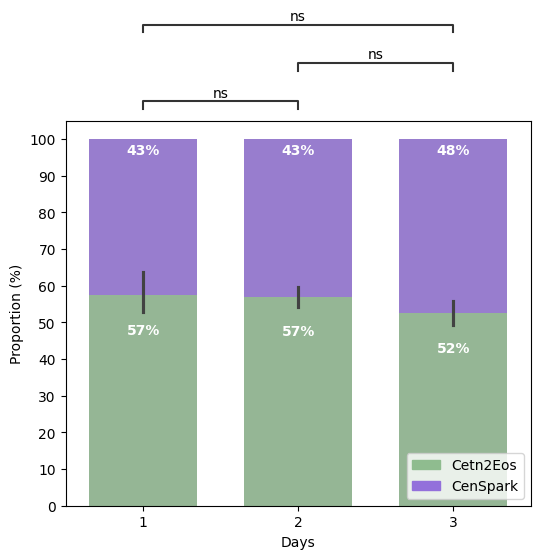

In [136]:
fig, ax = plt.subplots(figsize=(6, 5))
auto_proportion_df
sns.barplot(
    x = [1,2,3],
    y = [100,100,100],  
    color = "mediumpurple",
    #label="CenSpark",
    width=0.7,
    ax = ax
)
sns.barplot(
    data = auto_proportion_df.dropna(),
    x = "day",
    y = "auto_ct_percentage",
    hue="day",
    palette = ["darkseagreen"],
    legend=False,
    #label=["CetnEos"],
    width=0.7,
    ax = ax,
)

ax.set_xlabel("")
ax.set_ylim([0,105])
ax.set_yticks(np.arange(0,110,10))
ax.set_ylabel("Proportion (%)")#
ax.set_xlabel("Days")

custom_lines = [Patch(facecolor='darkseagreen', edgecolor='darkseagreen',
                         label='Cetn2Eos'),
                Patch(facecolor='mediumpurple', edgecolor='mediumpurple',
                         label='CenSpark')]
ax.legend(handles = custom_lines, loc = "lower right")

rects = ax.patches
labels = [str(100-57), str(100-57),str(100-52)]
for rect, label in zip(rects[0:3], labels):
    height = rect.get_height()
    ax.text(
        rect.get_x() + rect.get_width() / 2, height -5, label + "%", ha="center", va="bottom", color = "white", fontweight = "bold"
    )


for i in range(1,4):
    ax.bar_label(ax.containers[i],label_type="edge",padding=-30,fmt='%.0f%%', color = "white",fontweight="bold") 
#ax.set_xticklabels([""])
#ax.set_title("Proportion of auto-

pairs = [(1,2),(2,3),(1,3)]
annotator = Annotator(ax, pairs =pairs, data=auto_proportion_df, x="day", y="auto_ct_percentage")
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside')
annotator.apply_and_annotate()

In [137]:
accent_pallette = sns.color_palette("Pastel1")

C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\3516038240.py:13: UserWarning: 
The palette list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


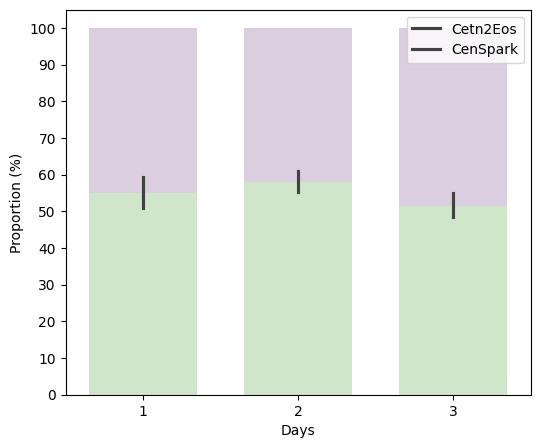

In [138]:
est_proportion_df = temporal_foci_df[["day","exp_idx","est_ct_percentage"]].dropna()

fig, ax = plt.subplots(figsize=(6, 5))
temporal_foci_df
sns.barplot(
    x = [1,2,3],
    y = [100,100,100],  
    color = accent_pallette[3],
    #label="CenSpark",
    width=0.7,
    ax = ax
)
sns.barplot(
    data = est_proportion_df.dropna(),
    x = "day",
    y = "est_ct_percentage",
    hue="day",
    palette = [accent_pallette[2]],
    legend=False,
    #label=["CetnEos"],
    width=0.7,
    ax = ax,
)

ax.set_xlabel("")
ax.set_ylim([0,105])
ax.set_yticks(np.arange(0,110,10))
ax.set_ylabel("Proportion (%)")#
ax.set_xlabel("Days")
ax.legend(["Cetn2Eos","CenSpark"])
#ax.set_xticklabels([""])
#ax.set_title("Proportion of auto-

#### Coloc 

In [139]:
all_foci_df = pd.concat([ct_4hpf, cs_4hpf,ct_1dpf,ct_2dpf,ct_3dpf,cs_1dpf,cs_2dpf,cs_3dpf])
all_foci_df

,exp_idx,label,prop,coloc,pr,upr,pi,upi,marker,day,...,apr,aupr,api,aupi,auto_nb,nb,nb_factor,auto_coloc,coloc_factor,est_nb
0,1,"""3e1""",70.1,42.8,NaN,NaN,NaN,NaN,Cetn2Eos,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,"""3e4""",75.5,31.8,0.593466,0.568601,75.343750,64.280844,Cetn2Eos,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,1,"""3e1""",29.9,100.0,NaN,NaN,NaN,NaN,CenSpark,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,"""3e4""",24.5,97.7,0.619675,0.575504,84.201923,62.700000,CenSpark,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,1,"""3e1""",NaN,73.3,NaN,NaN,NaN,NaN,Cetn2Eos,1,...,NaN,NaN,NaN,NaN,349.0,270.0,0.83,45.3,1.2,270.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,2,"""1e6""",NaN,NaN,NaN,NaN,NaN,NaN,CenSpark,3,...,0.60,0.60,82.13,46.89,389.0,NaN,0.81,82.5,1.1,315.09
2,2,"""1e7""",NaN,86.2,0.600000,0.530000,92.530000,57.970000,CenSpark,3,...,0.61,0.58,94.78,55.58,278.0,225.0,0.81,78.1,1.1,225.00
3,2,"""1e9""",NaN,NaN,NaN,NaN,NaN,NaN,CenSpark,3,...,0.65,0.58,106.83,46.85,317.0,NaN,0.81,85.2,1.1,256.77
4,2,"""2e3""",NaN,NaN,NaN,NaN,NaN,NaN,CenSpark,3,...,0.64,0.60,94.61,58.57,239.0,NaN,0.81,73.6,1.1,193.59


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: t-test independent samples, P_val:2.107e-01 t=1.281e+00
2 vs. 3: t-test independent samples, P_val:9.351e-01 t=8.219e-02
1 vs. 3: t-test independent samples, P_val:1.355e-01 t=1.545e+00


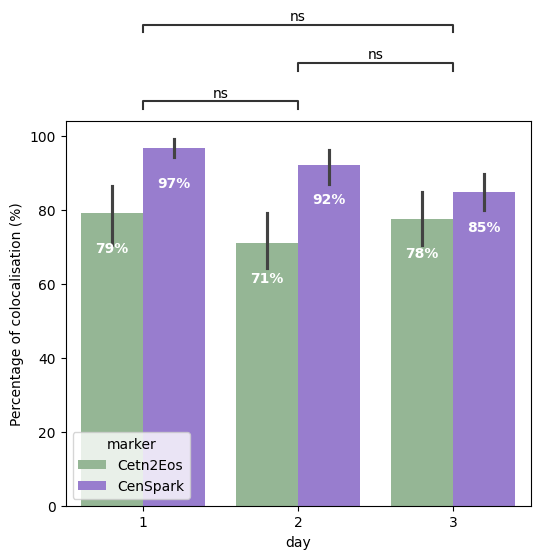

In [140]:
coloc_all_foci_df = all_foci_df[["day","marker","est_coloc"]].dropna()
coloc_all_foci_df_no_day1 = coloc_all_foci_df[coloc_all_foci_df["day"] != 0]
fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(
    data = coloc_all_foci_df_no_day1,
    x = "day",
    hue="marker",
    y = "est_coloc",
    palette=CT_CS_PALETTE,
    ax = ax,
)
# Add a line at y = 100
pairs = [(1,2),(2,3),(1,3)]
annotator = Annotator(ax, pairs =pairs, data=coloc_all_foci_df_no_day1, x="day", y="est_coloc")
annotator.configure(test="t-test_ind", text_format='star', loc='outside')
annotator.apply_and_annotate()
ax.set_ylabel("Percentage of colocalisation (%)")

for i in range(0,2):
    ax.bar_label(ax.containers[i],label_type="edge",padding=-30,fmt='%.0f%%', color = "white",fontweight="bold") 

#ax.set_title("Number of auto-detected double positive foci per half a somite over days")

#### Z diff 

C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\1943968796.py:3: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.barplot(


Text(0.5, 1.0, 'Axial displacement of paired foci over time')

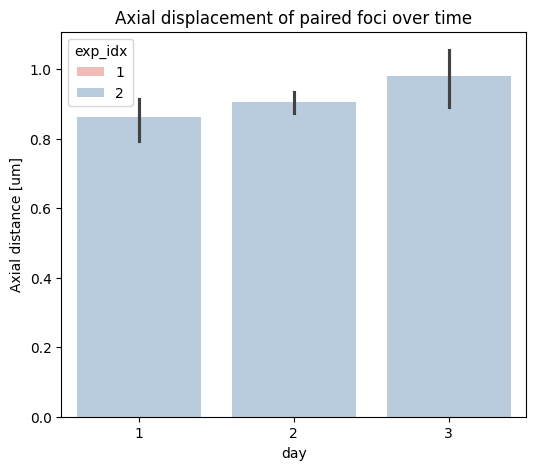

In [141]:
auto_double_pos_df = temporal_other_df[["day","exp_idx","auto_zdiff"]].dropna()
fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(
    data = auto_double_pos_df,
    x = "day",
    hue="exp_idx",
    y = "auto_zdiff",
    hue_order = [1,2],
    palette=sns.color_palette(palette="Pastel1"),
    ax = ax,
)

ax.set_ylabel("Axial distance [um]")
ax.set_title("Axial displacement of paired foci over time")

### Double positive over time

C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\1561662943.py:3: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.boxplot(
C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\1561662943.py:13: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.stripplot(data = auto_double_pos_df,


Text(0.5, 1.0, 'Number of auto-detected double positive foci per half a somite over days')

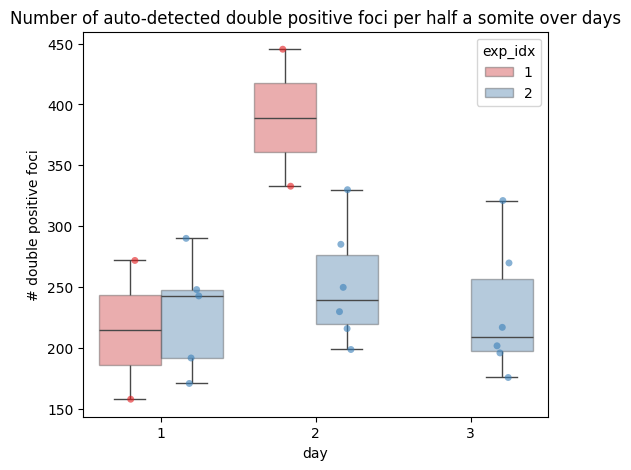

In [142]:
auto_double_pos_df = temporal_foci_df[["day","exp_idx","auto_double_pos"]].dropna()
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(
    data = auto_double_pos_df,
    x = "day",
    hue="exp_idx",
    y = "auto_double_pos",
    hue_order = [1,2],
    palette=sns.color_palette(palette="Set1"),
    boxprops={'alpha': 0.4},
    ax = ax,
)
sns.stripplot(data = auto_double_pos_df,
    x = "day",
    hue="exp_idx",
    y = "auto_double_pos",
    hue_order = [1,2],
    palette=sns.color_palette(palette="Set1"),
    dodge=True,
    alpha=0.6,
    legend=False,
    ax=ax)
ax.set_ylabel("# double positive foci")
ax.set_title("Number of auto-detected double positive foci per half a somite over days")

C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\1293938247.py:3: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.barplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:1.520e-01 U_stat=1.500e+01
2 vs. 3: Mann-Whitney-Wilcoxon test two-sided, P_val:1.419e-01 U_stat=3.600e+01


Text(0.5, 1.0, 'Number of auto-detected double positive foci per half a somite over days')

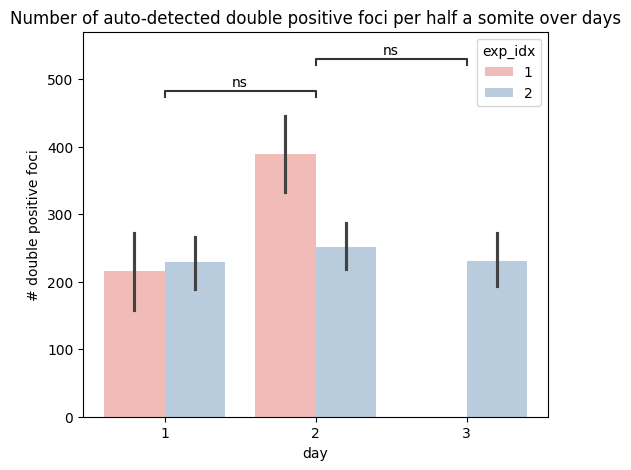

In [143]:
auto_double_pos_df = temporal_foci_df[["day","exp_idx","auto_double_pos"]].dropna()
fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(
    data = auto_double_pos_df,
    x = "day",
    hue="exp_idx",
    y = "auto_double_pos",
    hue_order = [1,2],
    palette=sns.color_palette(palette="Pastel1"),
    ax = ax,
)

pairs = [(1,2),(2,3)]
annotator = Annotator(ax, pairs =pairs, data=auto_double_pos_df, x="day", y="auto_double_pos")
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()

ax.set_ylabel("# double positive foci")
ax.set_title("Number of auto-detected double positive foci per half a somite over days")

C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\839594229.py:5: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.barplot(
C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\839594229.py:19: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.barplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:8.571e-01 U_stat=4.000e+00


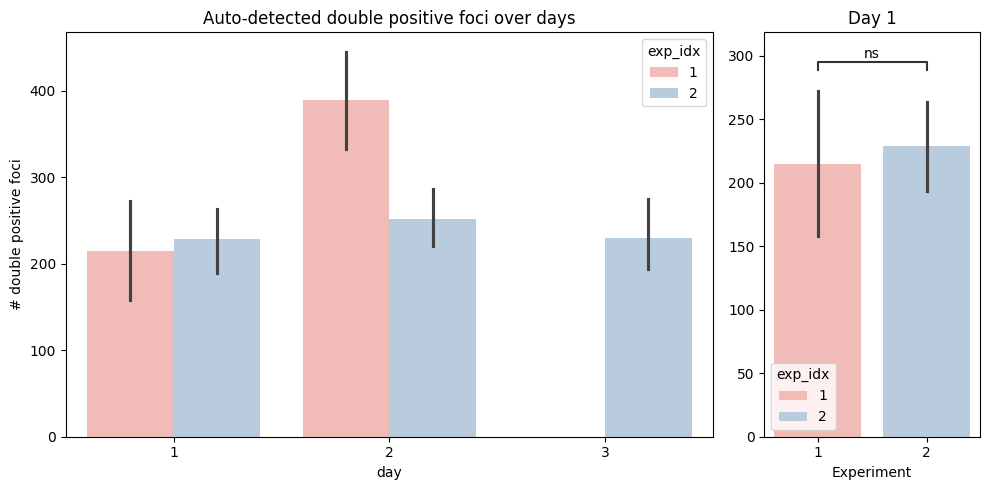

In [144]:
fig, (ax_main, ax_inset) = plt.subplots(1, 2, figsize=(10, 5),
                                          gridspec_kw={"width_ratios": [3, 1]})

# Main plot — all days
sns.barplot(
    data      = auto_double_pos_df,
    x         = "day",
    hue       = "exp_idx",
    y         = "auto_double_pos",
    hue_order = [1, 2],
    palette   = sns.color_palette(palette="Pastel1"),
    ax        = ax_main,
)
ax_main.set_ylabel("# double positive foci")
ax_main.set_title("Auto-detected double positive foci over days")

# Inset — day 1 only with stats
day1_df = auto_double_pos_df[auto_double_pos_df["day"] == 1]
sns.barplot(
    data      = day1_df,
    x         = "exp_idx",
    y         = "auto_double_pos",
    hue       = "exp_idx",
    hue_order = [1, 2],
    order     = [1, 2],
    palette   = sns.color_palette(palette="Pastel1"),
    ax        = ax_inset,
)
annotator = Annotator(
    ax_inset, pairs=[(1, 2)],
    data=day1_df, x="exp_idx", y="auto_double_pos",
    order=[1, 2],
)
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()

ax_inset.set_xlabel("Experiment")
ax_inset.set_ylabel("")
ax_inset.set_title("Day 1")

plt.tight_layout()
plt.show()

C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\1661714793.py:3: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.boxplot(
C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\1661714793.py:13: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.stripplot(data = double_pos_df,


Text(0.5, 1.0, 'Number of auto-detected double positive foci per half a somite over days')

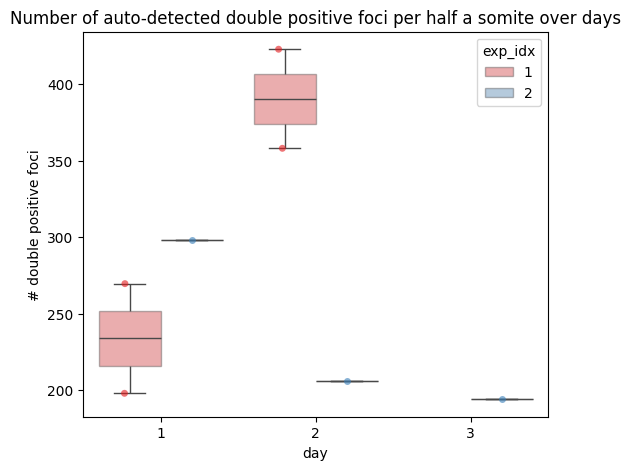

In [145]:
double_pos_df = temporal_foci_df[["day","exp_idx","double_pos"]].dropna()
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(
    data = double_pos_df,
    x = "day",
    hue="exp_idx",
    y = "double_pos",
    hue_order = [1,2],
    palette=sns.color_palette(palette="Set1"),
    boxprops={'alpha': 0.4},
    ax = ax,
)
sns.stripplot(data = double_pos_df,
    x = "day",
    hue="exp_idx",
    y = "double_pos",
    hue_order = [1,2],
    palette=sns.color_palette(palette="Set1"),
    dodge=True,
    alpha=0.6,
    legend=False,
    ax=ax)
ax.set_ylabel("# double positive foci")
ax.set_title("Number of auto-detected double positive foci per half a somite over days")

C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\2048364516.py:3: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.barplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:7.546e-01 U_stat=2.100e+01
1 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:7.546e-01 U_stat=2.100e+01


Text(0.5, 1.0, 'Number of double positive foci per half a somite over days')

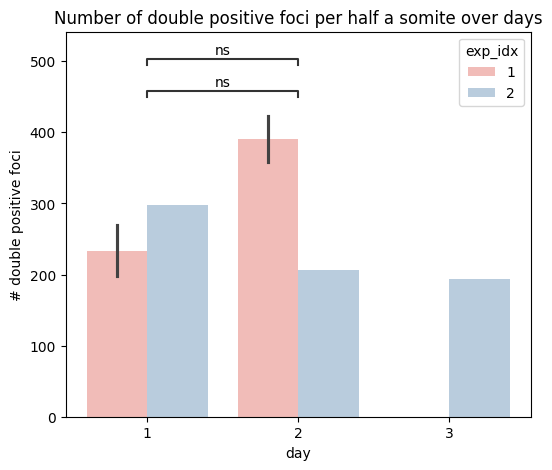

In [146]:
double_pos_df = temporal_foci_df[["day","exp_idx","double_pos"]].dropna()
fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(
    data = double_pos_df,
    x = "day",
    hue="exp_idx",
    y = "double_pos",
    hue_order = [1,2],
    palette=sns.color_palette(palette="Pastel1"),
    ax = ax,
)

pairs = [(1,2),(1,2)]
annotator = Annotator(ax, pairs =pairs, data=auto_proportion_df, x="day", y="auto_ct_percentage")
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()
ax.set_ylabel("# double positive foci")
ax.set_title("Number of double positive foci per half a somite over days")

## Nuclei over time

C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\2102073794.py:3: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.barplot(


Text(0.5, 1.0, 'Number of auto-detected nuclei per half a somite over days')

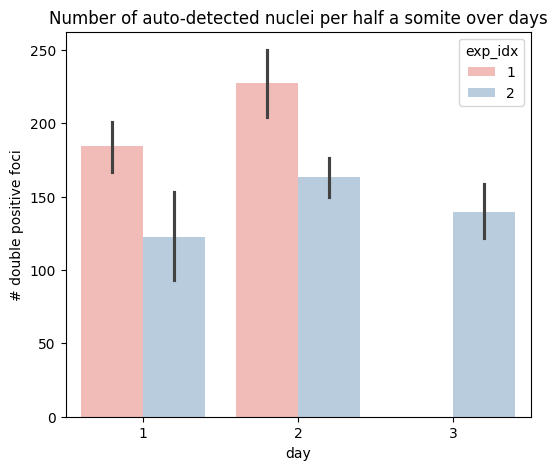

In [147]:
auto_nb_nucl_df = temporal_h2b_df[["day","exp_idx","auto_nb"]].dropna()
fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(
    data = auto_nb_nucl_df,
    x = "day",
    hue="exp_idx",
    y = "auto_nb",
    hue_order = [1,2],
    palette=sns.color_palette(palette="Pastel1"),
    ax = ax,
)
ax.set_ylabel("# double positive foci")
ax.set_title("Number of auto-detected nuclei per half a somite over days")

C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\1654479589.py:3: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.barplot(


Text(0.5, 1.0, 'Number of detected nuclei per half a somite over days')

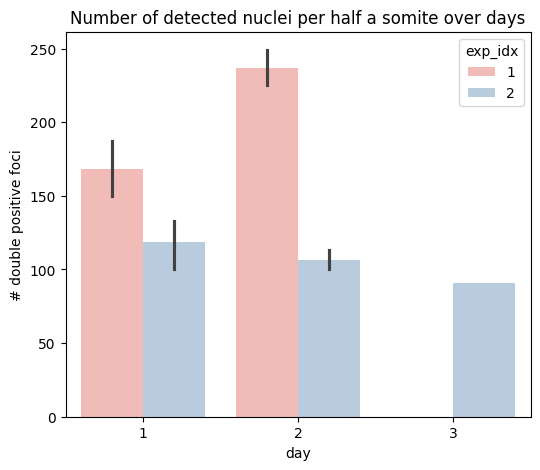

In [148]:
nb_nucl_df = temporal_h2b_df[["day","exp_idx","nb"]].dropna()
fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(
    data = nb_nucl_df,
    x = "day",
    hue="exp_idx",
    y = "nb",
    hue_order = [1,2],
    palette=sns.color_palette(palette="Pastel1"),
    ax = ax,
)
ax.set_ylabel("# double positive foci")
ax.set_title("Number of detected nuclei per half a somite over days")

##### Predication of curation

In [149]:
h2b_day1_exp1_factor = np.full(len(h2b_1dpf[h2b_1dpf["exp_idx"] == 1].index),0.9)
h2b_day1_exp2_factor = np.full(len(h2b_1dpf[h2b_1dpf["exp_idx"] == 2].index),0.75)

h2b_day2_exp1_factor = np.full(len(h2b_2dpf[h2b_2dpf["exp_idx"] == 1].index),0.8)
h2b_day2_exp2_factor = np.full(len(h2b_2dpf[h2b_2dpf["exp_idx"] == 2].index),0.6)

h2b_day3_factor = np.full(len(h2b_3dpf.index),0.8)
nucl_curation_factor = np.concat([h2b_day1_exp1_factor,h2b_day1_exp2_factor,h2b_day2_exp1_factor,h2b_day2_exp2_factor,h2b_day3_factor])
temporal_h2b_df["estimated_nb"] = temporal_h2b_df["auto_nb"] * nucl_curation_factor

C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\4027229216.py:3: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.barplot(


Text(0.5, 1.0, 'Number of estimated detected nuclei per half a somite over days')

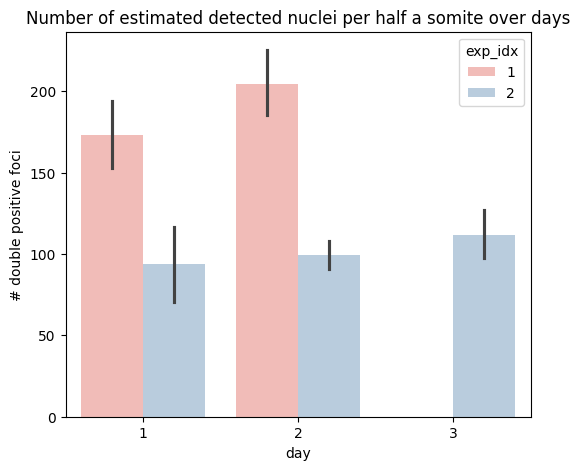

In [150]:
nb_nucl_df = temporal_h2b_df[["day","exp_idx","est_nb"]].dropna()
fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(
    data = nb_nucl_df,
    x = "day",
    hue="exp_idx",
    y = "est_nb",
    hue_order = [1,2],
    palette=sns.color_palette(palette="Pastel1"),
    ax = ax,
)
ax.set_ylabel("# double positive foci")
ax.set_title("Number of estimated detected nuclei per half a somite over days")

### Centriole number per nuclei

In [151]:
temporal_foci_nucl = temporal_foci_df.loc[:,["exp_idx","label","day"]]
temporal_foci_nucl["auto_cent_nucl"] = temporal_foci_df["auto_double_pos"]/temporal_h2b_df["auto_nb"]
temporal_foci_nucl["cent_nucl"] = temporal_foci_df["double_pos"]/temporal_h2b_df["nb"]
temporal_foci_nucl["est_cent_nucl"] = temporal_foci_df["est_double_pos"]/temporal_h2b_df["est_nb"]

C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\3807855073.py:4: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.boxplot(
C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\3807855073.py:14: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.stripplot(data = auto_cent_nucl_df,


Text(0.5, 1.0, 'Number of auto-detected double positive foci per half a somite over days')

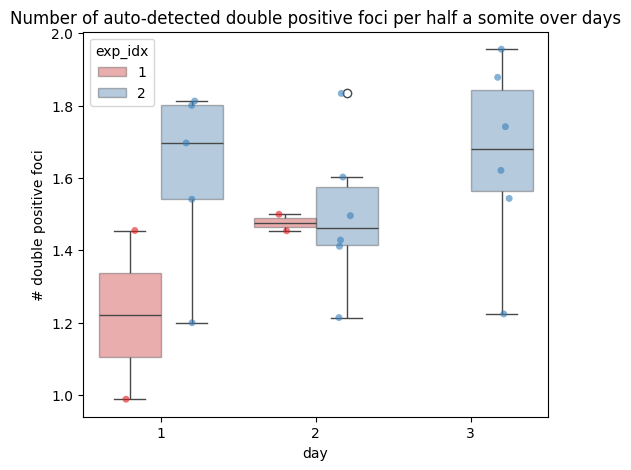

In [152]:
auto_cent_nucl_df = temporal_foci_nucl[["day","exp_idx","auto_cent_nucl"]].dropna()

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(
    data = auto_cent_nucl_df,
    x = "day",
    hue="exp_idx",
    y = "auto_cent_nucl",
    hue_order = [1,2],
    palette=sns.color_palette(palette="Set1"),
    boxprops={'alpha': 0.4},
    ax = ax,
)
sns.stripplot(data = auto_cent_nucl_df,
    x = "day",
    hue="exp_idx",
    y = "auto_cent_nucl",
    hue_order = [1,2],
    palette=sns.color_palette(palette="Set1"),
    dodge=True,
    alpha=0.6,
    legend=False,
    ax=ax)
ax.set_ylabel("# double positive foci")
ax.set_title("Number of auto-detected double positive foci per half a somite over days")

C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\2621441881.py:3: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.barplot(


Text(0.5, 1.0, 'Number of auto-detected double positive foci per half a somite over days')

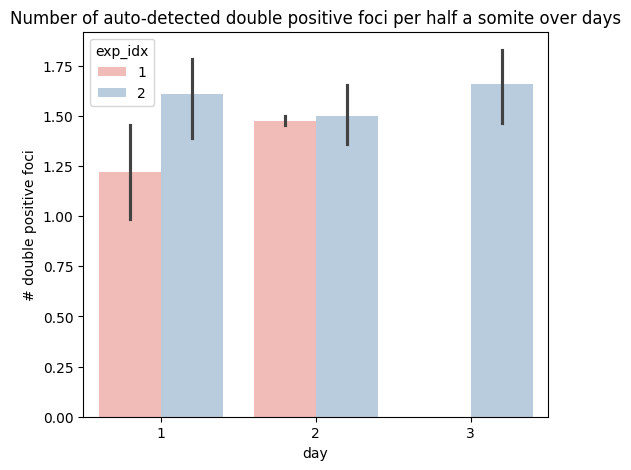

In [153]:
auto_cent_nucl_df = temporal_foci_nucl[["day","exp_idx","auto_cent_nucl"]].dropna()
fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(
    data = auto_cent_nucl_df,
    x = "day",
    hue="exp_idx",
    y = "auto_cent_nucl",
    hue_order = [1,2],
    palette=sns.color_palette(palette="Pastel1"),
    ax = ax,
)
ax.set_ylabel("# double positive foci")
ax.set_title("Number of auto-detected double positive foci per half a somite over days")

C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\2174910744.py:4: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.boxplot(
C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\2174910744.py:14: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.stripplot(data = cent_nucl_df,


Text(0.5, 1.0, 'Number of double positive foci per half a somite over days')

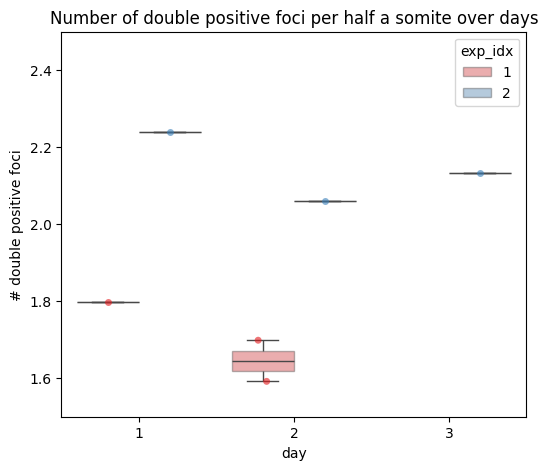

In [154]:
cent_nucl_df = temporal_foci_nucl[["day","exp_idx","cent_nucl"]].dropna()

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(
    data = cent_nucl_df,
    x = "day",
    hue="exp_idx",
    y = "cent_nucl",
    hue_order = [1,2],
    palette=sns.color_palette(palette="Set1"),
    boxprops={'alpha': 0.4},
    ax = ax,
)
sns.stripplot(data = cent_nucl_df,
    x = "day",
    hue="exp_idx",
    y = "cent_nucl",
    hue_order = [1,2],
    palette=sns.color_palette(palette="Set1"),
    dodge=True,
    alpha=0.6,
    legend=False,
    ax=ax)
ax.set_ylim([1.5,2.5])
ax.set_ylabel("# double positive foci")
ax.set_title("Number of double positive foci per half a somite over days")

C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\1896543318.py:2: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.barplot(


Text(0.5, 1.0, 'Number of double positive foci per half a somite over days')

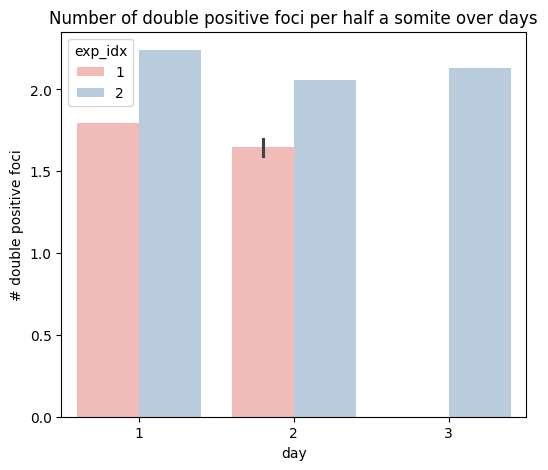

In [155]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(
    data = cent_nucl_df,
    x = "day",
    hue="exp_idx",
    y = "cent_nucl",
    hue_order = [1,2],
    palette=sns.color_palette(palette="Pastel1"),
    ax = ax,
)
ax.set_ylabel("# double positive foci")
ax.set_title("Number of double positive foci per half a somite over days")

Let's check if there is a diff between the 2

C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\4072380578.py:3: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.barplot(


Text(0.5, 1.0, 'Number of auto-detected double positive foci per half a somite over days')

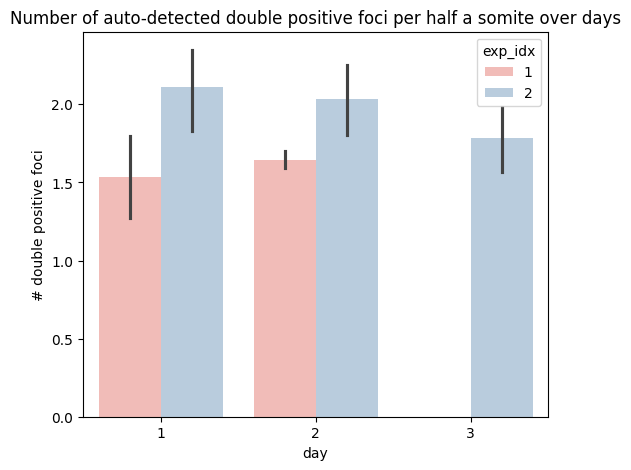

In [156]:
est_cent_nucl_df = temporal_foci_nucl[["day","exp_idx","est_cent_nucl"]].dropna()
fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(
    data = est_cent_nucl_df,
    x = "day",
    hue="exp_idx",
    y = "est_cent_nucl",
    hue_order = [1,2],
    palette=sns.color_palette(palette="Pastel1"),
    ax = ax,
)
ax.set_ylabel("# double positive foci")
ax.set_title("Number of auto-detected double positive foci per half a somite over days")

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: t-test independent samples, P_val:6.961e-01 t=4.034e-01
2 vs. 3: t-test independent samples, P_val:1.987e-01 t=1.376e+00
1 vs. 3: t-test independent samples, P_val:1.227e-01 t=1.703e+00


[Text(0, -40, '2.11'), Text(0, -40, '2.03'), Text(0, -40, '1.79')]

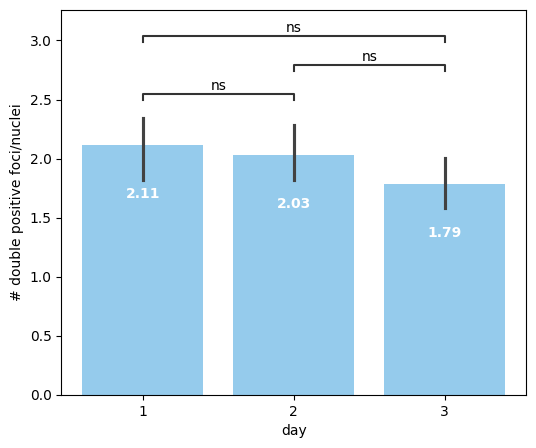

In [157]:
exp2_temporal_foci_nucl = temporal_foci_nucl[temporal_foci_nucl["exp_idx"] == 2]
exp2_est_cent_nucl_df = exp2_temporal_foci_nucl[["day","est_cent_nucl"]].dropna()
fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(
    data = exp2_est_cent_nucl_df,
    x = "day",
    y = "est_cent_nucl",
    hue_order = [1,2],
    color="lightskyblue",
    ax = ax,
)

pairs = [(1,2),(2,3),(1,3)]
annotator = Annotator(ax, pairs =pairs, data=exp2_est_cent_nucl_df, x="day", y="est_cent_nucl")
annotator.configure(test='t-test_ind', text_format='star', loc='inside') #Mann-Whitney
annotator.apply_and_annotate()
ax.set_ylabel("# double positive foci/nuclei")
ax.bar_label(ax.containers[0],label_type="edge",padding=-40,fmt='%.2f', color = "white",fontweight="bold") 

#ax.set_title("Number of auto-detected double positive foci per half a somite over days")

#### Distance nuclei centrioles

In [158]:
temporal_other_df[temporal_other_df["day"]== 2]

,exp_idx,label,auto_zdiff,z_diff,auto_dist,dist,dist_factor,day,est_dist,zdiff
0,1,"""3e3""",NaN,NaN,NaN,NaN,1.3,2,NaN,NaN
1,1,"""3e4""",NaN,NaN,NaN,NaN,1.3,2,NaN,NaN
2,1,"""3e5""",NaN,NaN,NaN,NaN,1.3,2,NaN,NaN
3,1,"""4e6""",NaN,NaN,NaN,2.0,1.3,2,2.000,0.923
4,1,"""5e3""",NaN,NaN,NaN,NaN,1.3,2,NaN,NaN
5,1,"""6e6""",NaN,NaN,NaN,NaN,1.3,2,NaN,NaN
6,1,"""6e8",NaN,NaN,NaN,NaN,1.3,2,NaN,NaN
7,1,"""6e9""",NaN,NaN,NaN,NaN,1.3,2,NaN,NaN
8,2,"""1e2""",0.85,NaN,2.10,NaN,1.3,2,2.730,NaN
9,2,"""1e7""",0.92,NaN,1.86,NaN,1.3,2,2.418,NaN


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: t-test independent samples, P_val:1.390e-04 t=-5.962e+00
2 vs. 3: t-test independent samples, P_val:1.350e-03 t=-4.257e+00


Text(37.722222222222214, 0.5, 'Distance [um]')

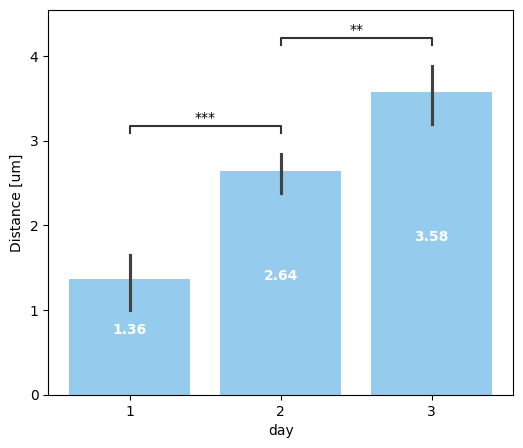

In [159]:
est_dist_nucl_df = temporal_other_df[["day","exp_idx","est_dist"]].dropna()
fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(
    data = est_dist_nucl_df,
    x = "day",
    #hue="exp_idx",
    y = "est_dist",
    #hue_order = [1,2],
    color="lightskyblue",
    #estimator="sum",
    ax = ax,
)
ax.bar_label(ax.containers[0],label_type="center",padding=5,fmt='%.2f', color = "white",fontweight="bold") 
pairs = [(1,2),(2,3)]
annotator = Annotator(ax, pairs =pairs, data=est_dist_nucl_df, x="day", y="est_dist")
annotator.configure(test='t-test_ind', text_format='star', loc='inside')
annotator.apply_and_annotate()
ax.set_ylabel("Distance [um]")
#ax.set_title("Mean foci distance to closest nuclei")

In [160]:
all_foci_df

,exp_idx,label,prop,coloc,pr,upr,pi,upi,marker,day,...,apr,aupr,api,aupi,auto_nb,nb,nb_factor,auto_coloc,coloc_factor,est_nb
0,1,"""3e1""",70.1,42.8,NaN,NaN,NaN,NaN,Cetn2Eos,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,"""3e4""",75.5,31.8,0.593466,0.568601,75.343750,64.280844,Cetn2Eos,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,1,"""3e1""",29.9,100.0,NaN,NaN,NaN,NaN,CenSpark,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,"""3e4""",24.5,97.7,0.619675,0.575504,84.201923,62.700000,CenSpark,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,1,"""3e1""",NaN,73.3,NaN,NaN,NaN,NaN,Cetn2Eos,1,...,NaN,NaN,NaN,NaN,349.0,270.0,0.83,45.3,1.2,270.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,2,"""1e6""",NaN,NaN,NaN,NaN,NaN,NaN,CenSpark,3,...,0.60,0.60,82.13,46.89,389.0,NaN,0.81,82.5,1.1,315.09
2,2,"""1e7""",NaN,86.2,0.600000,0.530000,92.530000,57.970000,CenSpark,3,...,0.61,0.58,94.78,55.58,278.0,225.0,0.81,78.1,1.1,225.00
3,2,"""1e9""",NaN,NaN,NaN,NaN,NaN,NaN,CenSpark,3,...,0.65,0.58,106.83,46.85,317.0,NaN,0.81,85.2,1.1,256.77
4,2,"""2e3""",NaN,NaN,NaN,NaN,NaN,NaN,CenSpark,3,...,0.64,0.60,94.61,58.57,239.0,NaN,0.81,73.6,1.1,193.59


In [161]:
intensity_all_df = pd.melt(
    all_foci_df,
    id_vars=["day", "marker"],
    value_vars=["epi", "eupi"],
    var_name="Colocalizing",
    value_name="intensity"
)

radius_all_df = pd.melt(
    all_foci_df,
    id_vars=["day", "marker"],
    value_vars=["epr", "eupr"],
    var_name="Colocalizing",
    value_name="radius"
)

intensity_all_df["Colocalizing"] = intensity_all_df["Colocalizing"].map({
    "epi": "Yes",
    "eupi": "No"
})

radius_all_df["Colocalizing"] = radius_all_df["Colocalizing"].map({
    "epr": "Yes",
    "eupr": "No"
})

In [162]:
intensity_all_df
ct_intensity_all_df = intensity_all_df[intensity_all_df["marker"] == "Cetn2Eos"]
cs_intensity_all_df = intensity_all_df[intensity_all_df["marker"] == "CenSpark"]

ct_radius_all_df = radius_all_df[radius_all_df["marker"] == "Cetn2Eos"]
cs_radius_all_df = radius_all_df[radius_all_df["marker"] == "CenSpark"]

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: t-test independent samples, P_val:5.867e-01 t=-5.586e-01
1 vs. 2: t-test independent samples, P_val:2.789e-01 t=-1.108e+00
2 vs. 3: t-test independent samples, P_val:7.768e-02 t=1.843e+00


C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\3307781875.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["4hpf","1dpf","2dpf","3dpf"])


Text(0.5, 25.722222222222214, 'Embryonic stage')

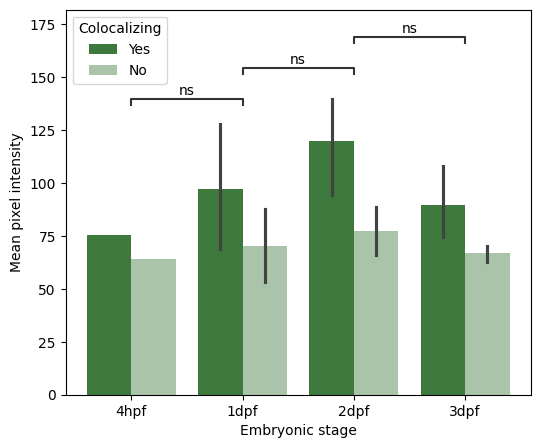

In [163]:
fig, ax = plt.subplots(figsize=(6, 5))

sns.barplot(
    data = ct_intensity_all_df,
    x = "day",
    y = "intensity",
    hue = "Colocalizing",
    palette=["darkgreen","darkseagreen"],
    alpha=0.8,
    ax = ax
)
pairs = [(0,1),(1,2),(2,3)]
annotator = Annotator(ax, pairs =pairs, data=ct_intensity_all_df, x="day", y="intensity")
annotator.configure(test='t-test_ind', text_format='star', loc='inside')
annotator.apply_and_annotate()
ax.set_ylabel("Mean pixel intensity")
ax.set_xticklabels(["4hpf","1dpf","2dpf","3dpf"])
ax.set_xlabel("Embryonic stage")
#.legend(["Yes","No"])

C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\3519851895.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["4hpf","1dpf","2dpf","3dpf"])


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: t-test independent samples, P_val:3.409e-02 t=2.391e+00
0 vs. 2: t-test independent samples, P_val:3.326e-01 t=1.004e+00
0 vs. 3: t-test independent samples, P_val:1.092e-01 t=1.730e+00


(<Axes: xlabel='Embryonic stage', ylabel='Mean radius [um]'>,
  <statannotations.Annotation.Annotation at 0x1d1e8e29ed0>])

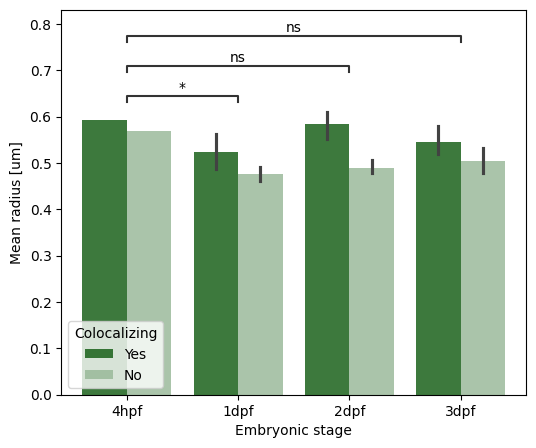

In [164]:
fig, ax = plt.subplots(figsize=(6, 5))

sns.barplot(
    data = ct_radius_all_df,
    x = "day",
    y = "radius",
    hue = "Colocalizing",
    palette=["darkgreen","darkseagreen"],
    alpha=0.8,
    ax = ax
)

plt.ylabel("Mean radius [um]")
ax.set_xticklabels(["4hpf","1dpf","2dpf","3dpf"])
ax.set_xlabel("Embryonic stage")
pairs = [(0,1),(0,2),(0,3)]
annotator = Annotator(ax, pairs =pairs, data=ct_radius_all_df, x="day", y="radius")
annotator.configure(test='t-test_ind', text_format='star', loc='inside')
annotator.apply_and_annotate()

C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\2213223340.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["4hpf","1dpf","2dpf","3dpf"])


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: t-test independent samples, P_val:9.832e-01 t=-2.146e-02
1 vs. 2: t-test independent samples, P_val:5.524e-01 t=6.027e-01
2 vs. 3: t-test independent samples, P_val:9.668e-01 t=-4.210e-02


(<Axes: xlabel='Embryonic stage', ylabel='Mean pixel intensity'>,
  <statannotations.Annotation.Annotation at 0x1d1e93cfc40>])

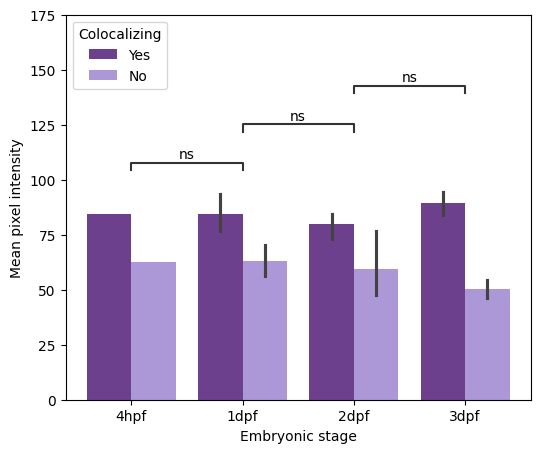

In [165]:
fig, ax = plt.subplots(figsize=(6, 5))

sns.barplot(
    data = cs_intensity_all_df,
    x = "day",
    y = "intensity",
    hue = "Colocalizing",
    palette=["indigo","mediumpurple"],
    alpha=0.8,
    ax = ax
)
ax.set_ylabel("Mean pixel intensity")
ax.set_xticklabels(["4hpf","1dpf","2dpf","3dpf"])
ax.set_xlabel("Embryonic stage")
ax.set_yticks(np.arange(0,200,25))
pairs = [(0,1),(1,2),(2,3)]
annotator = Annotator(ax, pairs =pairs, data=cs_intensity_all_df, x="day", y="intensity")
annotator.configure(test='t-test_ind', text_format='star', loc='inside')
annotator.apply_and_annotate()
#.legend(["Yes","No"])

C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\3809328946.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["4hpf","1dpf","2dpf","3dpf"])


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: t-test independent samples, P_val:3.662e-01 t=9.391e-01
1 vs. 2: t-test independent samples, P_val:4.893e-01 t=-7.022e-01
2 vs. 3: t-test independent samples, P_val:7.626e-01 t=3.056e-01


(<Axes: xlabel='Embryonic stage', ylabel='Mean radius [um]'>,
  <statannotations.Annotation.Annotation at 0x1d1e92d6f50>])

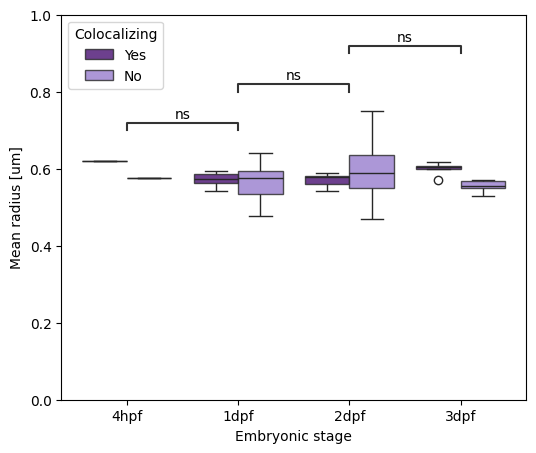

In [166]:
fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(
    data = cs_radius_all_df,
    x = "day",
    y = "radius",
    hue = "Colocalizing",
    palette=["indigo","mediumpurple"],
    boxprops={"alpha": 0.8},
    ax = ax
)

plt.ylabel("Radius [um]")
ax.set_ylabel("Mean radius [um]")
ax.set_xticklabels(["4hpf","1dpf","2dpf","3dpf"])
ax.set_xlabel("Embryonic stage")
ax.set_ylim([0,1])
pairs = [(0,1),(1,2),(2,3)]
annotator = Annotator(ax, pairs =pairs, data=cs_radius_all_df, x="day", y="radius")
annotator.configure(test='t-test_ind', text_format='star', loc='inside')
annotator.apply_and_annotate()

C:\Users\voland\AppData\Local\Temp\2\ipykernel_4960\2105690127.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["4hpf","1dpf","2dpf","3dpf"])


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: t-test independent samples, P_val:3.662e-01 t=9.391e-01
1 vs. 2: t-test independent samples, P_val:4.893e-01 t=-7.022e-01
2 vs. 3: t-test independent samples, P_val:7.626e-01 t=3.056e-01


(<Axes: xlabel='Embryonic stage', ylabel='Mean radius [um]'>,
  <statannotations.Annotation.Annotation at 0x1d1e92d7eb0>])

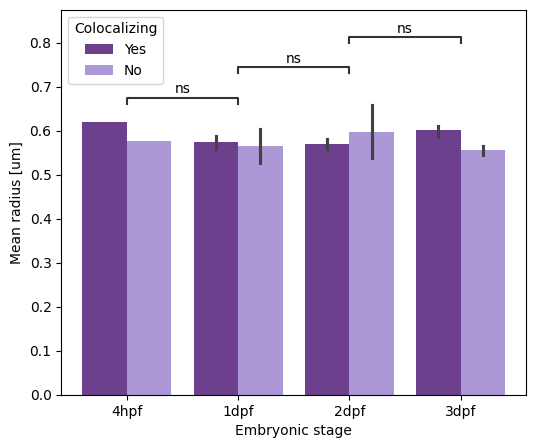

In [167]:
fig, ax = plt.subplots(figsize=(6, 5))

sns.barplot(
    data = cs_radius_all_df,
    x = "day",
    y = "radius",
    hue = "Colocalizing",
    palette=["indigo","mediumpurple"],
    alpha=0.8,
    ax = ax
)

plt.ylabel("Radius [um]")
ax.set_ylabel("Mean radius [um]")
ax.set_xticklabels(["4hpf","1dpf","2dpf","3dpf"])
ax.set_xlabel("Embryonic stage")
pairs = [(0,1),(1,2),(2,3)]
annotator = Annotator(ax, pairs =pairs, data=cs_radius_all_df, x="day", y="radius")
annotator.configure(test='t-test_ind', text_format='star', loc='inside')
annotator.apply_and_annotate()